# XGBoost AML Baseline - SAML-D
**Kaan Gogcay | AML Research**

This notebook implements and evaluates two iterations of an XGBoost model for Anti-Money Laundering detection on the SAML-D dataset. The notebook is structured as follows:

<h2>Contents</h2>

- [Data Preperation](#data-preperation)
    - [Load Splits](#load-splits)
- [Iteration 1 - Baseline](#iteration-1---baseline)
    - [Model Configuration](#model-configuration)
    - [Evaluation Metric](#evaluation-metric)
    - [Save Iteration 1 Model](#save-iteration-1-model)
- [Iteration 2 - Grid Search](#iteration-2---grid-search)
    - [Grid Search Design](#grid-search-design)
    - [Grid Search Execution](#grid-search-execution)
    - [Save Grid Search Results](#save-grid-search-results)
    - [Load Saved Grid Search Results](#load-saved-grid-search-results)
    - [Results Summary](#results-summary)
    - [Retrain on Best Parameters](#retrain-on-best-parameters)
    - [Save Iteration 2 Model](#save-iteration-2-model)
- [Iteration 3 - Bayesian Optimisation (Optuna)](#iteration-3---bayesian-optimisation-optuna)
    - [Optuna Research Design](#optuna-search-design)
    - [Retrain on Best Parameters](#retrain-on-best-parameters)
    - [Save Iteration 3 Model](#save-iteration-3-model)
- [Comparison - Iteration 1 vs Iteration 2 vs Iteration 3](#comparison---iteration-1-vs-iteration-2-vs-iteration-3)
    - [Load Best Model](#load-best-model)
- [Explainability - SHAP Analysis](#explainability---shap-analysis)
    - [Why SHAP?](#why-shap)
    - [Global Feature Importance](#global-feature-importance)
    - [Global Feature Importance (in %)](#global-feature-importance-in-)
    - [Individual Transaction Explanations](#individual-transaction-explanations)
- [Summary](#summary)
- [References](#references)

---

# Data Preperation

All data exploration and preperation is documented in `Data_Exploration_and_Preperation_v1.7.ipynb`. 

## Load Splits

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report

# Load splits
train_df = pd.read_csv('../Data/dataset_FE_2/train.csv')
val_df   = pd.read_csv('../Data/dataset_FE_2/val.csv')
test_df  = pd.read_csv('../Data/dataset_FE_2/test.csv')

print(f'Split sizes — Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    rate = split['Is_laundering'].mean() * 100
    print(f'  {name} laundering rate: {rate:.4f}%')

Split sizes — Train: 6,653,396 | Val: 1,425,728 | Test: 1,425,728
  Train laundering rate: 0.1017%
  Val laundering rate: 0.0990%
  Test laundering rate: 0.1190%


In [8]:
# Prepare features
# Laundering_type dropped — label leakage. Retained in CSVs for post-hoc SHAP analysis.
DROP_COLS = ['Is_laundering', 'Laundering_type']

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df['Is_laundering']
    return X, y

X_train, y_train = prepare(train_df)
X_val,   y_val   = prepare(val_df)
X_test,  y_test  = prepare(test_df)

cat_cols = X_train.select_dtypes('object').columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

print(f'Features ({len(X_train.columns)}): {X_train.columns.tolist()}')
print(f'Categorical features: {cat_cols}')

Features (27): ['Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'sender_tx_count', 'sender_amount_mean', 'sender_amount_std', 'sender_amount_min', 'sender_amount_max', 'sender_unique_receivers', 'sender_unique_currencies', 'sender_unique_locations', 'receiver_tx_count', 'receiver_amount_mean', 'receiver_amount_std', 'receiver_unique_senders', 'receiver_unique_currencies', 'receiver_unique_locations', 'pair_tx_count', 'fan_out_ratio', 'fan_in_ratio', 'is_cross_currency', 'is_cross_border']
Categorical features: ['Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


---

# Iteration 1 - Baseline

Iteration 1 trains XGBoost using default hyperparameters, with only the parameters strictly required by the dataset and evaluation methodology overridden. This establishes the baseline performance that Iteration 2 attempts to improve upon.

## Model Configuration

| Parameter | Value | Justification |
|---|---|---|
| `device` | `cuda` | Allows GPU acceleration | 
| `enable_categorical` | `True` | Native categorical support; avoids manual encoding |
| `scale_pos_weight` | `neg / pos` (~982) | Mathematically correct handling of 0.104% class imbalance; recommended by XGBoost documentation |
| `eval_metric` | `aucpr` | Matches primary evaluation metric; consistent with industry practice at ING and ABN AMRO |
| `early_stopping_rounds` | `50` | Prevents overfitting; actual tree count determined by validation performance |
| `random_state` | `42` | Reproducibility safeguard |
| All others | XGBoost defaults | Defaults represent the author's recommended starting configuration [(XGBoost Documentation)](#references) |

## Evaluation Metric

AUPRC (Area Under the Precision Recall Curve) is selected because:
1. It is specifically designed for imbalanced datasets
2. Both ING and ABN AMRO use AUPRC as their primary evaluation metric in production ([Attard & de Bruijn, 2026](#references); [Menon & Nguyen, 2026](#references))
3. It evaluates the precision-recall trade-off across all classification thresholds simultaneously, allowing for live evaluation for a potential prototype.

In [4]:
# Class imbalance weight
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
spw = neg / pos
print(f'Class balance — Neg: {neg:,} | Pos: {pos:,} | scale_pos_weight: {spw:.1f}')

# Train model
model = xgb.XGBClassifier(
    tree_method          ='hist',
    device='cuda',
    enable_categorical   =True,
    scale_pos_weight     =spw,
    eval_metric          ='aucpr',
    early_stopping_rounds=50,
    random_state         =42,
    n_jobs               =-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print(f'\nBest iteration: {model.best_iteration}')

Class balance — Neg: 6,646,632 | Pos: 6,764 | scale_pos_weight: 982.6
[0]	validation_0-aucpr:0.78776
[50]	validation_0-aucpr:0.90826
[99]	validation_0-aucpr:0.90247

Best iteration: 63


In [5]:
# Move model to CPU for prediction — data is on CPU, model trained on GPU
model.get_booster().set_param('device', 'cpu')

# Evaluate — primary metric: AUPRC
def evaluate(model, X, y, split_name):
    y_proba = model.predict_proba(X)[:, 1]
    auprc   = average_precision_score(y, y_proba)
    print(f'\n{"="*50}')
    print(f'{split_name} AUPRC: {auprc:.4f}')
    return y_proba, auprc

# Evaluate on validation set only
# Test set is reserved for final evaluation in the Comparison section
y_val_proba, val_auprc = evaluate(model, X_val, y_val, 'Iteration 1 — Validation')


Iteration 1 — Validation AUPRC: 0.9087


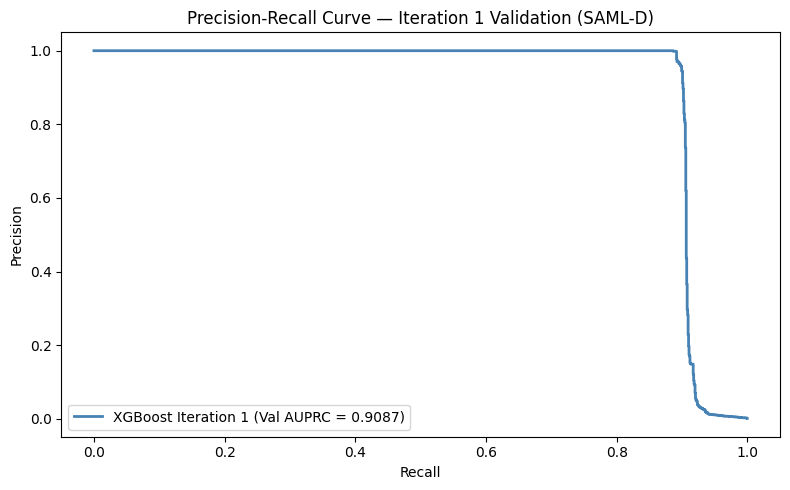

Saved: pr_curve_xgboost_val.png


In [ ]:
# Precision-Recall Curve — Validation Set
precision, recall, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='steelblue', lw=2,
         label=f'XGBoost Iteration 1 (Val AUPRC = {val_auprc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Iteration 1 Validation (SAML-D)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_xgboost_val.png', dpi=150)
plt.show()
print('Saved: pr_curve_xgboost_val.png')

## Save Iteration 1 Model

In [6]:
model.save_model('xgboost_aml_baseline.json')
print('Model saved: xgboost_aml_baseline.json')
print(f'Iteration 1 Validation AUPRC: {val_auprc:.4f}')

Model saved: xgboost_aml_baseline.json
Iteration 1 Validation AUPRC: 0.9087


---

# Iteration 2 - Grid Search

Iteration 1 used mostly default parameters. It attempt to improve the model, this iteration applies a grid search over the parameters identified as most tunable by [Probst et al. (2019)](#references). Each combination trains on `X_train` and is evaluated on `X_val` using AUPRC. The test set remains untouched until final evaluation.

## Grid Search Design

Parameter values are derived from three sources: the derived tuning ranges of [Probst et al. (2019)](#references), who benchmarked XGBoost hyperparameter sensitivity across 38 datasets and reported 5th and 95th percentile optimal values, and reported that eta and booster are the most tunable XGBoost parameters; the 1st place IEEE-CIS Fraud Detection solution of [Deotte & Yakovlev (2019)](#references), which provides competition-validated values on a comparable fraud detection task; and the XGBoost documentation [(XGBoost Developers, 2024)](#references) for package defaults.

| Parameter | Doc Default | Grid Values | Justification |
|---|---|---|---|
| `eta` | 0.3 | `[0.002, 0.02, 0.18, 0.3, 0.355]` | Probst et al. (2019) q0.05, Deotte & Yakovlev (2019), quantile-midpoint, Doc default, Probst et al. (2019) q0.95 |
| `subsample` | 1.0 | `[0.5, 0.75, 0.8, 0.958, 1.0]` | Probst et al. (2019) q0.05, quantile-midpoint, Deotte & Yakovlev (2019), Probst et al. (2019) q0.95, Doc default |
| `min_child_weight` | 1 | `[1, 4, 7]` | Probst et al. (2019) q0.05 & Doc default, quantile-midpoint, q0.95 |
| `booster` | gbtree | `[gbtree, dart]` | Of the three available boosters, only `gbtree` and `dart` support categorical features — both are included. |

**Total combinations: 5 × 5 × 3 × 2 = 150**

All parameters not listed above remain at XGBoost defaults, identical to Iteration 1.

## Grid Search Execution

In [7]:
from sklearn.model_selection import ParameterGrid
import time

# Fixed parameters — identical to Iteration 1
# Only the grid parameters below are varied
fixed_params = dict(
    tree_method          ='hist',
    device               ='cuda',
    enable_categorical   =True,
    scale_pos_weight     =spw,
    eval_metric          ='aucpr',
    early_stopping_rounds=50,
    random_state         =42,
    n_jobs               =-1,
)

# Grid derived from:
# - Probst et al. (2019): empirically derived q0.05 and q0.95 tuning ranges across 38 datasets
# - Deotte & Yakovlev (2019): 1st place IEEE-CIS Fraud Detection Competition values
# - XGBoost documentation (XGBoost Developers, 2024): package defaults
# See markdown above for per-parameter justification
param_grid = {
    'eta'             : [0.002, 0.02, 0.18, 0.3, 0.355],  # Probst q0.05, Deotte, midpoint, default, Probst q0.95
    'subsample'       : [0.5, 0.75, 0.8, 0.958, 1.0],     # Probst q0.05, midpoint, Deotte, Probst q0.95, default
    'min_child_weight': [1, 4, 7],                          # Probst q0.05 & default, midpoint, Probst q0.95
    'booster'         : ['gbtree', 'dart'],             # Probst et al. (2019) most tunable parameter, default included
}

grid = list(ParameterGrid(param_grid))
print(f'Total combinations to evaluate: {len(grid)}')
print(f'Estimated time at ~45s per combination: ~{len(grid)*45//60} minutes')

Total combinations to evaluate: 150
Estimated time at ~45s per combination: ~112 minutes


In [8]:
# # Run grid search
# # Each combination trains on X_train, scores on X_val using AUPRC
# # Test set is never used during this process

# results = []
# start_total = time.time()

# for i, params in enumerate(grid, 1):
#     start = time.time()

#     m = xgb.XGBClassifier(**params, **fixed_params)
#     m.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         verbose=False,
#     )

#     val_proba = m.predict_proba(X_val)[:, 1]
#     val_auprc = average_precision_score(y_val, val_proba)

#     elapsed = time.time() - start
#     results.append({**params, 'val_auprc': val_auprc, 'best_iteration': m.best_iteration})

#     print(f'[{i:>3}/{len(grid)}] AUPRC: {val_auprc:.4f} | '
#           f'iter: {m.best_iteration:>3} | '
#           f'eta={params["eta"]} '
#           f'sub={params["subsample"]} '
#           f'mcw={params["min_child_weight"]} '
#           f'booster={params["booster"]} '
#           f'({elapsed:.0f}s)')

# total_time = time.time() - start_total
# print(f'\nGrid search complete in {total_time/60:.1f} minutes')

## Save Grid Search Results

In [9]:
# # Save grid search results — run this immediately after the grid search
# # Allows reloading without rerunning the full 150 combinations
# results_df = pd.DataFrame(results).sort_values('val_auprc', ascending=False)
# results_df.to_csv('grid_search_results.csv', index=False)
# print('Saved: grid_search_results.csv')

## Load Saved Grid Search Results

If the grid search has already been run, results can be loaded directly from disk without rerunning the full search.

In [ ]:
# Load grid search results — skip rerunning if already saved
results_df = pd.read_csv('grid_search_results.csv')
print(f'Loaded {len(results_df)} results')
print(results_df.sort_values('val_auprc', ascending=False).head(10).to_string(index=False))

Loaded 150 results
booster   eta  min_child_weight  subsample  val_auprc  best_iteration
 gbtree 0.300                 1        0.8   0.910749              41
 gbtree 0.300                 7        0.8   0.910378              20
 gbtree 0.300                 4        0.8   0.910109              20
 gbtree 0.355                 7        0.8   0.909780              24
   dart 0.300                 7        0.8   0.909705              25
 gbtree 0.355                 4        0.8   0.909048              24
 gbtree 0.355                 1        0.8   0.908857              20
   dart 0.300                 1        0.8   0.908739              34
 gbtree 0.300                 7        1.0   0.908715              63
   dart 0.300                 7        1.0   0.908715              63


## Results Summary

In [11]:
# Results summary
# results_df = pd.DataFrame(results).sort_values('val_auprc', ascending=False)

print('Top 10 configurations by Validation AUPRC:')
print(results_df.head(10).to_string(index=False))

# Best configuration
best = results_df.iloc[0]
print(f'\nBest configuration:')
for col in results_df.columns:
    print(f'  {col}: {best[col]}')

Top 10 configurations by Validation AUPRC:
booster   eta  min_child_weight  subsample  val_auprc  best_iteration
 gbtree 0.300                 1        0.8   0.910749              41
 gbtree 0.300                 7        0.8   0.910378              20
 gbtree 0.300                 4        0.8   0.910109              20
 gbtree 0.355                 7        0.8   0.909780              24
   dart 0.300                 7        0.8   0.909705              25
 gbtree 0.355                 4        0.8   0.909048              24
 gbtree 0.355                 1        0.8   0.908857              20
   dart 0.300                 1        0.8   0.908739              34
   dart 0.300                 7        1.0   0.908715              63
 gbtree 0.300                 7        1.0   0.908715              63

Best configuration:
  booster: gbtree
  eta: 0.3
  min_child_weight: 1
  subsample: 0.8
  val_auprc: 0.9107493780407514
  best_iteration: 41


## Retrain on Best Parameters

The optimal parameter combination identified by the grid search is used to retrain the model on the full training set. The model is evaluated on the validation set.

In [12]:
# Extract best parameters
best_params = results_df.iloc[0][list(param_grid.keys())].to_dict()

# Convert types — ParameterGrid can return numpy types
# min_child_weight needs to be int
best_params['min_child_weight'] = int(best_params['min_child_weight'])

print('Retraining with best parameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

# Retrain on full training set
tuned_model = xgb.XGBClassifier(**best_params, **fixed_params)
tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)
print(f'\nBest iteration: {tuned_model.best_iteration}')

Retraining with best parameters:
  eta: 0.3
  subsample: 0.8
  min_child_weight: 1
  booster: gbtree


[0]	validation_0-aucpr:0.77649
[50]	validation_0-aucpr:0.90635
[90]	validation_0-aucpr:0.89935

Best iteration: 41


In [9]:
# Move tuned model to CPU for prediction
tuned_model.get_booster().set_param('device', 'cpu')

# Evaluate on validation set only
# Test set is reserved for final evaluation in the Comparison section
y_val_proba_t, val_auprc_t = evaluate(tuned_model, X_val, y_val, 'Iteration 2 — Validation')


Iteration 2 — Validation AUPRC: 0.9136


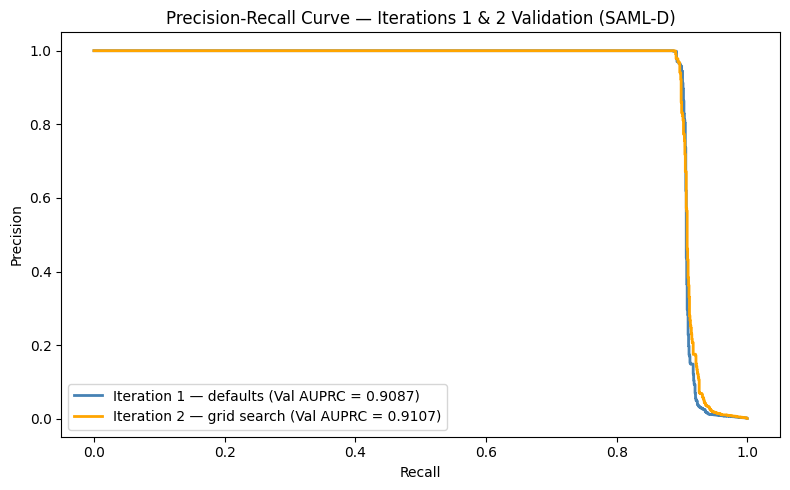

In [29]:
# [Iteration 3c]

precision_t, recall_t, _ = precision_recall_curve(y_val, y_val_proba_t)

plt.figure(figsize=(8, 5))
plt.plot(recall,   precision,   color='steelblue', lw=2, label=f'Iteration 1 — defaults (Val AUPRC = {val_auprc:.4f})')
plt.plot(recall_t, precision_t, color='orange',    lw=2, label=f'Iteration 2 — grid search (Val AUPRC = {val_auprc_t:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Iterations 1 & 2 Validation (SAML-D)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_one_and_two.png', dpi=150)
plt.show()


## Save Iteration 2 Model

The tuned model is saved separately from the Iteration 1 baseline. The better-performing model of the two will be used as the XGBoost reference score when comparing against the DQN.

In [14]:
tuned_model.save_model('xgboost_aml_tuned.json')
print('Model saved: xgboost_aml_tuned.json')
print(f'Iteration 1 Validation AUPRC: {val_auprc:.4f}')
print(f'Iteration 2 Validation AUPRC: {val_auprc_t:.4f}')

Model saved: xgboost_aml_tuned.json
Iteration 1 Validation AUPRC: 0.9087
Iteration 2 Validation AUPRC: 0.9107


---

---

# Iteration 3 - Bayesian Optimisation (Optuna)

Grid search evaluates a fixed set of discrete parameter combinations. For continuous parameters such as `eta` and `subsample`, this means the search is limited to the specific values defined in the grid and cannot find values between them. Bayesian optimisation addresses this by building a probabilistic model of the parameter space and concentrating evaluations in regions that are likely to produce good results, allowing it to search continuous ranges more efficiently than grid search.

## Optuna Search Design

The same parameters as the grid search are optimised, but `eta` and `subsample` are treated as continuous rather than discrete. `min_child_weight` is searched as an integer range and `booster` remains categorical with the same two options.

| Parameter | Search Type | Range | Justification |
|---|---|---|---|
| `eta` | Continuous (log scale) | `[0.0001, 1]` | Full possible range [(XGBoost Developers, 2024)](#references) (0 is impossible in optuna) |
| `subsample` | Continuous | `[0.0001, 1]` | Full possible range [(XGBoost Developers, 2024)](#references) (0 is impossible in optuna) |
| `min_child_weight` | Integer | `[1, 7]` | Probst et al. (2019) q0.05 & Doc default, quantile-midpoint, q0.95 (already discrete so just staying in the same range, 0 is impossible in optuna)  |
| `booster` | Categorical | `[gbtree, dart]` | Same as grid search, only boosters supporting categorical features |

100 Trials have been executed. Trial #22 appeared to be the best trial (which is on the lower side) and therefore more than 100 trials have not been explored.

All parameters not listed above remain at XGBoost defaults, identical to Iterations 1 and 2.

In [17]:
# [Iteration 3a]
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Fixed parameters — identical to Iterations 1 and 2
fixed_params_optuna = dict(
    tree_method        = 'hist',
    device             = 'cuda',
    enable_categorical = True,
    scale_pos_weight   = spw,
    eval_metric        = 'aucpr',
    early_stopping_rounds = 50,
    random_state       = 42,
    n_jobs             = -1,
)

def objective(trial):
    params = {
        # Continuous parameters — Optuna searches the full range
        'eta'             : trial.suggest_float('eta',       0.0001, 1,  log=True), # full possible range // 0 impossible
        'subsample'       : trial.suggest_float('subsample', 0.0001, 1), # full possible range // 0 impossible
        # Discrete parameters — same as grid search
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7), # probst went from 0 to seven so we replicate
        'booster'         : trial.suggest_categorical('booster', ['gbtree', 'dart']),
    }

    m = xgb.XGBClassifier(**params, **fixed_params_optuna)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    m.get_booster().set_param('device', 'cpu')
    y_proba = m.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_proba)

# Run optimisation — 150 trials to match grid search budget
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest trial AUPRC: {study.best_value:.4f}')
print(f'Best parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


  0%|          | 0/100 [00:00<?, ?it/s]


Best trial AUPRC: 0.9136
Best parameters:
  eta: 0.23811612043960928
  subsample: 0.26462546715504953
  min_child_weight: 4
  booster: gbtree


## Retrain on Best Parameters

In [18]:
# [Iteration 3b]
# Retrain on best Optuna parameters
optuna_params = study.best_params.copy()

optuna_model = xgb.XGBClassifier(
    **optuna_params,
    **fixed_params_optuna
)

optuna_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

print(f'\nBest iteration: {optuna_model.best_iteration}')


[0]	validation_0-aucpr:0.77364
[50]	validation_0-aucpr:0.90153
[84]	validation_0-aucpr:0.88956

Best iteration: 35



Iteration 3 — Validation AUPRC: 0.9136


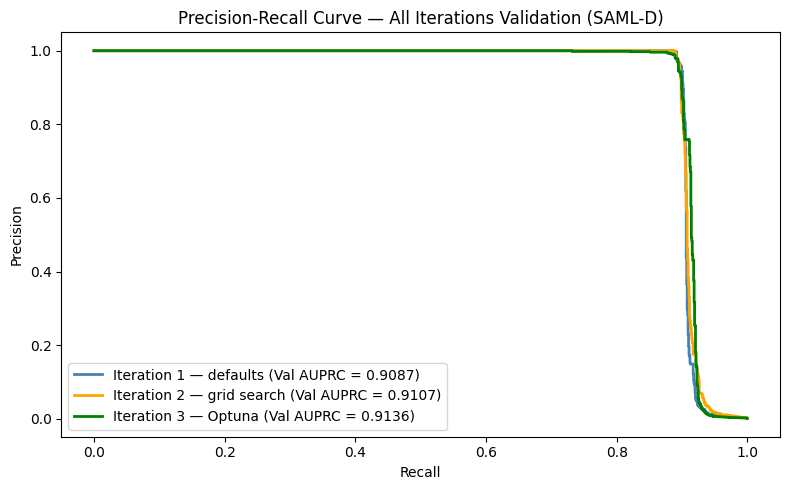

In [30]:
# [Iteration 3c]
optuna_model.get_booster().set_param('device', 'cpu')

y_val_proba_o, val_auprc_o = evaluate(optuna_model, X_val, y_val, 'Iteration 3 — Validation')

y_val_pred_o = (y_val_proba_o >= 0.5).astype(int)

# Precision-Recall Curve
precision_o, recall_o, _ = precision_recall_curve(y_val, y_val_proba_o)

plt.figure(figsize=(8, 5))
plt.plot(recall,   precision,   color='steelblue', lw=2, label=f'Iteration 1 — defaults (Val AUPRC = {val_auprc:.4f})')
plt.plot(recall_t, precision_t, color='orange',    lw=2, label=f'Iteration 2 — grid search (Val AUPRC = {val_auprc_t:.4f})')
plt.plot(recall_o, precision_o, color='green',     lw=2, label=f'Iteration 3 — Optuna (Val AUPRC = {val_auprc_o:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Iterations Validation (SAML-D)')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_all_iterations.png', dpi=150)
plt.show()


## Save Iteration 3 Model

In [27]:
# [Iteration 3d]
optuna_model.save_model('xgboost_aml_optuna.json')
print('Model saved: xgboost_aml_optuna.json')
print(f'Iteration 3 Validation AUPRC: {val_auprc_o:.4f}')


Model saved: xgboost_aml_optuna.json
Iteration 3 Validation AUPRC: 0.9136


# Comparison - Iteration 1 vs Iteration 2 vs Iteration 3

All models were trained on identical data under identical conditions. The only difference is the hyperparameter configuration. For the comparison, all models are evaluated on the testset for the first and only time. The better-performing model on the test set becomes the XGBoost benchmark that the DQN must match or exceed.


Iteration 1 — Test (final) AUPRC: 0.9232

Iteration 2 — Test (final) AUPRC: 0.9260

Iteration 3 — Test (final) AUPRC: 0.9275
COMPARISON — Test Set
Iteration 1 (defaults)     Test AUPRC: 0.9232
Iteration 2 (grid search)  Test AUPRC: 0.9260
Iteration 3 (Optuna)       Test AUPRC: 0.9275


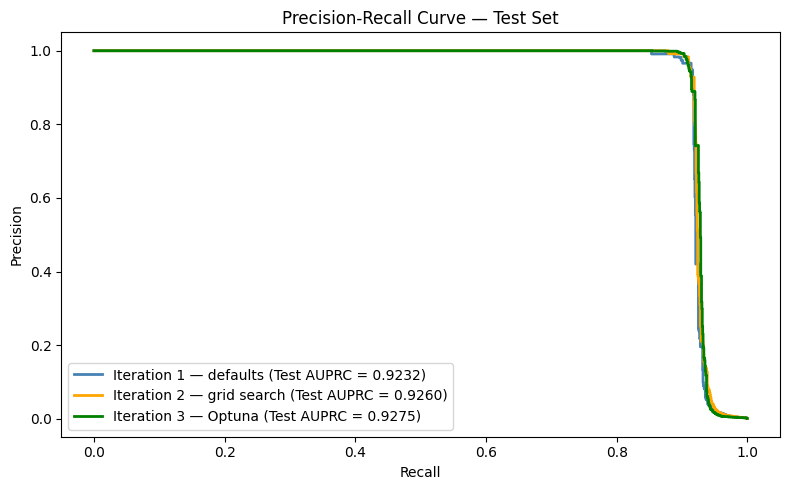

In [40]:
# Evaluate all three models on test set — first and only time
y_test_proba,   test_auprc   = evaluate(model,        X_test, y_test, 'Iteration 1 — Test (final)')
y_test_proba_t, test_auprc_t = evaluate(tuned_model,  X_test, y_test, 'Iteration 2 — Test (final)')
y_test_proba_o, test_auprc_o = evaluate(optuna_model, X_test, y_test, 'Iteration 3 — Test (final)')

print('=' * 50)
print('COMPARISON — Test Set')
print('=' * 50)
print(f'Iteration 1 (defaults)     Test AUPRC: {test_auprc:.4f}')
print(f'Iteration 2 (grid search)  Test AUPRC: {test_auprc_t:.4f}')
print(f'Iteration 3 (Optuna)       Test AUPRC: {test_auprc_o:.4f}')

# Precision-Recall Curves — Test Set
precision_test_1, recall_test_1, _ = precision_recall_curve(y_test, y_test_proba)
precision_test_2, recall_test_2, _ = precision_recall_curve(y_test, y_test_proba_t)
precision_test_3, recall_test_3, _ = precision_recall_curve(y_test, y_test_proba_o)

plt.figure(figsize=(8, 5))
plt.plot(recall_test_1, precision_test_1, color='steelblue', lw=2, label=f'Iteration 1 — defaults (Test AUPRC = {test_auprc:.4f})')
plt.plot(recall_test_2, precision_test_2, color='orange',    lw=2, label=f'Iteration 2 — grid search (Test AUPRC = {test_auprc_t:.4f})')
plt.plot(recall_test_3, precision_test_3, color='green',     lw=2, label=f'Iteration 3 — Optuna (Test AUPRC = {test_auprc_o:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Test Set')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve_test_all_iterations.png', dpi=150)
plt.show()

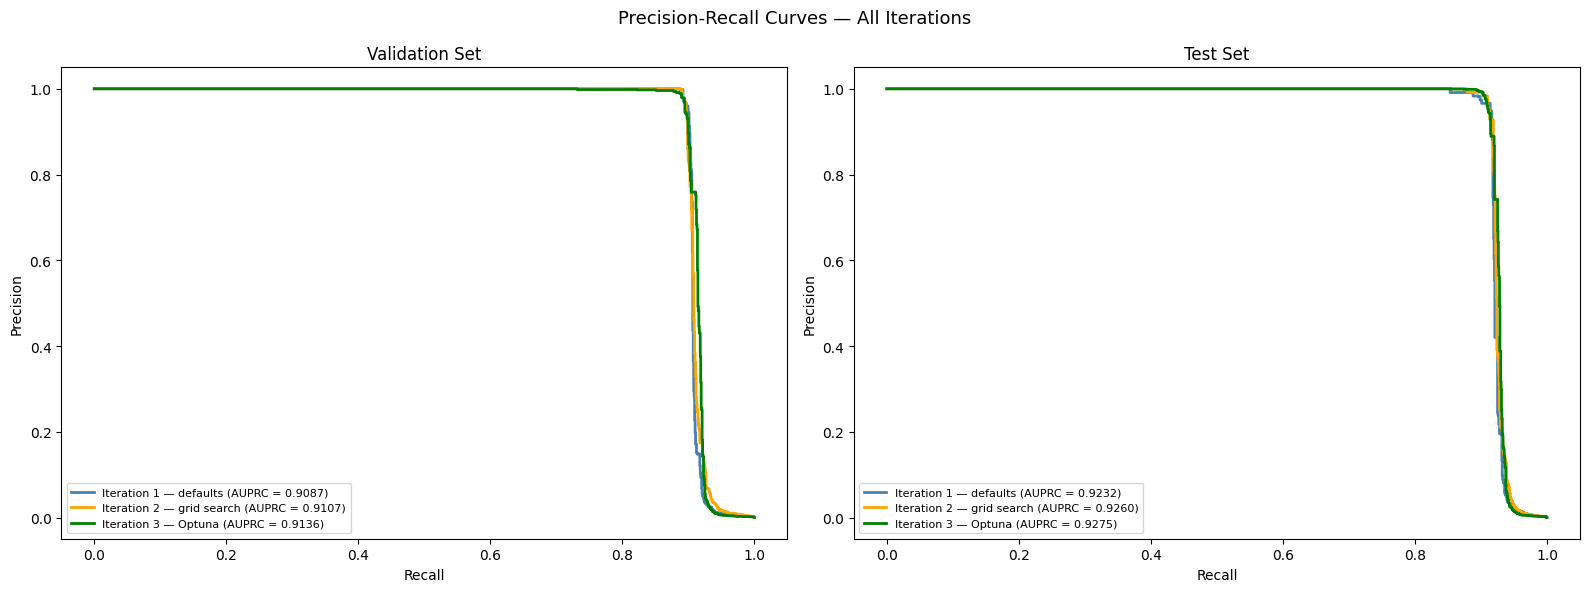

In [41]:
# Combined plot — Validation (left) and Test (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Validation
axes[0].plot(recall,   precision,   color='steelblue', lw=2, label=f'Iteration 1 — defaults (AUPRC = {val_auprc:.4f})')
axes[0].plot(recall_t, precision_t, color='orange',    lw=2, label=f'Iteration 2 — grid search (AUPRC = {val_auprc_t:.4f})')
axes[0].plot(recall_o, precision_o, color='green',     lw=2, label=f'Iteration 3 — Optuna (AUPRC = {val_auprc_o:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Validation Set')
axes[0].legend(fontsize=8)

# Right — Test
axes[1].plot(recall_test_1, precision_test_1, color='steelblue', lw=2, label=f'Iteration 1 — defaults (AUPRC = {test_auprc:.4f})')
axes[1].plot(recall_test_2, precision_test_2, color='orange',    lw=2, label=f'Iteration 2 — grid search (AUPRC = {test_auprc_t:.4f})')
axes[1].plot(recall_test_3, precision_test_3, color='green',     lw=2, label=f'Iteration 3 — Optuna (AUPRC = {test_auprc_o:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Test Set')
axes[1].legend(fontsize=8)

fig.suptitle('Precision-Recall Curves — All Iterations', fontsize=13)
plt.tight_layout()
plt.savefig('pr_curve_val_test_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Load Best Model

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report

# Load splits
train_df = pd.read_csv('../dataset_FE_2/train.csv')
val_df   = pd.read_csv('../dataset_FE_2/val.csv')
test_df  = pd.read_csv('../dataset_FE_2/test.csv')

# Prepare features
DROP_COLS = ['Is_laundering', 'Laundering_type']

def prepare(split_df):
    X = split_df.drop(columns=DROP_COLS)
    y = split_df['Is_laundering']
    return X, y

X_train, y_train = prepare(train_df)
X_val,   y_val   = prepare(val_df)
X_test,  y_test  = prepare(test_df)

cat_cols = X_train.select_dtypes('object').columns.tolist()
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col]   = X_val[col].astype('category')
    X_test[col]  = X_test[col].astype('category')

# Load all three models and select best by test AUPRC
candidates = {
    'Iteration 1 (defaults)'   : 'xgboost_aml_baseline.json',
    'Iteration 2 (grid search)': 'xgboost_aml_tuned.json',
    'Iteration 3 (Optuna)'     : 'xgboost_aml_optuna.json',
}

best_label = None
best_auprc = -1
best_model = None
best_proba = None

for label, path in candidates.items():
    m = xgb.XGBClassifier()
    m.load_model(path)
    m.get_booster().set_param('device', 'cpu')
    proba = m.predict_proba(X_test)[:, 1]
    auprc = average_precision_score(y_test, proba)
    print(f'{label} — Test AUPRC: {auprc:.4f}')
    if auprc > best_auprc:
        best_auprc = auprc
        best_label = label
        best_model = m
        best_proba = proba

print(f'\nBest model: {best_label}')
print(f'Test AUPRC: {best_auprc:.4f}')

# Rebuild explainer on best model
explainer = shap.TreeExplainer(best_model)
print('Explainer ready')

Iteration 1 (defaults) — Test AUPRC: 0.9232
Iteration 2 (grid search) — Test AUPRC: 0.9260
Iteration 3 (Optuna) — Test AUPRC: 0.9275

Best model: Iteration 3 (Optuna)
Test AUPRC: 0.9275
Explainer ready


---

# Summary

This notebook implemented and evaluated three iterations of an XGBoost model for Anti-Money Laundering detection on the SAML-D dataset. Two preliminary configurations were also evaluated for context. `Raw Features Only` shows model performance without any feature engineering. `Data Leaked Feature Engineering` shows the result of computing account profiles before splitting the data, artificially inflating the results.

| | Raw features only | Data leaked | Iteration 1 | Iteration 2 | Iteration 3 |
|---|---|---|---|---|---|
| **Validation AUPRC** | 0.0648 | 0.9986 | 0.9087 | 0.9107 | 0.9136 |
| **Test AUPRC** | 0.0850 | 0.9974 | 0.9232 | 0.9260 | 0.9275 |
| **Parameters** | Defaults | Defaults | Defaults | Grid search | Bayesian optimisation |

The improvement from Iteration 1 to Iteration 2 (grid search) was 0.0028 AUPRC, and from Iteration 2 to Iteration 3 (Bayesian optimisation) was 0.0015 AUPRC. The diminishing returns suggest the model is approaching the performance ceiling achievable through hyperparameter tuning alone on this feature set. Further gains would likely require architectural changes or additional feature engineering rather than continued tuning.

The model trained in iteration 3 is used as the XGBoost benchmark for comparison against the Deep Q-Network in the main research question.

---

# References

###### Attard, M. and de Bruijn, L. (2026). Machine learning binnen ING. Guest lecture at Hogeschool van Amsterdam. Personal notes taken during presentation.

###### Deotte, C. and Yakovlev, K. (2019). 1st place solution - part 2. https://www.kaggle.com/competitions/ieee-fraud-detection/writeups/fraudsquad-1st-place-solution-part-2.

###### Menon, S. and Nguyen, T. (2026). AML at ABN AMRO. Guest lecture at Hogeschool van Amsterdam. Personal notes taken during presentation.

###### Probst, P., Boulesteix, A-L., and Bischl, B. (2019). Tunability: Importance of hyperparameters of machine learning algorithms. Journal of Machine Learning Research, 20:1–32. http://jmlr.org/papers/v20/18-444.html.

###### XGBoost Developers (2024). XGBoost Parameters. https://xgboost.readthedocs.io/en/stable/parameter.html.